<h1>Learning with <b>selected</b> data</h1>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

FEATURES = ["RR_l_0", "RR_l_0/RR_l_1", "RR_r_0", "R_val", "P_val", "signal_std"]

# 1) Load your existing 80% learning data
learn_df = pd.read_csv("original_selected_features_data/learn_valid_80.csv")  # load CSV [web:79]

# 2) If you want a validation split from the 80%: e.g., 80/20 of the 80%
X_learn = learn_df[FEATURES]
y_learn = learn_df["label"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X_learn, y_learn, test_size=0.20, random_state=42, shuffle=True, stratify=y_learn
)  # stratified split preserves balance in train/valid [web:136]

# 3) Train KNN on the training portion
knn_selected_features = KNeighborsClassifier()
knn_selected_features.fit(X_train, y_train)

# 4) Validate
y_pred = knn_selected_features.predict(X_valid)
print("Validation accuracy:", accuracy_score(y_valid, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_valid, y_pred))
print("Classification report:\n", classification_report(y_valid, y_pred))


Validation accuracy: 0.96875
Confusion matrix:
 [[158   2]
 [  8 152]]
Classification report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       160
           1       0.99      0.95      0.97       160

    accuracy                           0.97       320
   macro avg       0.97      0.97      0.97       320
weighted avg       0.97      0.97      0.97       320



In [2]:
test_df  = pd.read_csv("original_selected_features_data/test_20.csv")         # load test data  [web:79]

X_test,  y_test  = test_df[FEATURES],  test_df["label"]

# 3) Evaluate on the 20% test set
y_pred = knn_selected_features.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

Test accuracy: 0.9475
Confusion matrix:
 [[197   3]
 [ 18 182]]
Classification report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95       200
           1       0.98      0.91      0.95       200

    accuracy                           0.95       400
   macro avg       0.95      0.95      0.95       400
weighted avg       0.95      0.95      0.95       400



<h1>Learning with <b>tsne</b> data</h1>

In [3]:
# 1) Load your existing 80% learning data
learn_df = pd.read_csv("tsne_data/learn_valid_80.csv")  # load CSV [web:79]

# 2) If you want a validation split from the 80%: e.g., 80/20 of the 80%
X_learn = learn_df[["tsne_x", "tsne_y"]]
y_learn = learn_df["label"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X_learn, y_learn, test_size=0.20, random_state=42, shuffle=True, stratify=y_learn
)  # stratified split preserves balance in train/valid [web:136]

# 3) Train KNN on the training portion
knn_tsne = KNeighborsClassifier()
knn_tsne.fit(X_train, y_train)

# 4) Validate
y_pred = knn_tsne.predict(X_valid)
print("Validation accuracy:", accuracy_score(y_valid, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_valid, y_pred))
print("Classification report:\n", classification_report(y_valid, y_pred))

Validation accuracy: 0.9625
Confusion matrix:
 [[157   3]
 [  9 151]]
Classification report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96       160
           1       0.98      0.94      0.96       160

    accuracy                           0.96       320
   macro avg       0.96      0.96      0.96       320
weighted avg       0.96      0.96      0.96       320



In [4]:
test_df  = pd.read_csv("tsne_data/test_20.csv")

X_test,  y_test  = test_df[["tsne_x", "tsne_y"]],  test_df["label"]

# 3) Evaluate on the 20% test set
y_pred = knn_tsne.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


Test accuracy: 0.9475
Confusion matrix:
 [[196   4]
 [ 17 183]]
Classification report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95       200
           1       0.98      0.92      0.95       200

    accuracy                           0.95       400
   macro avg       0.95      0.95      0.95       400
weighted avg       0.95      0.95      0.95       400



<h1>Learning with <b>all</b> data</h1>

In [5]:
learn_df = pd.read_csv("original_all_features_data/learn_valid_80.csv")  # load CSV [web:79]

# keep only numeric columns
numeric_cols = learn_df.select_dtypes(include=[np.number]).columns

# features = all numeric columns except label (in case label is numeric)
feature_cols = numeric_cols.drop("label") if "label" in numeric_cols else numeric_cols

X_learn = learn_df[feature_cols]
y_learn = learn_df["label"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X_learn, y_learn, test_size=0.20, random_state=42, shuffle=True, stratify=y_learn
)


# 3) Train KNN on the training portion
knn_all_feautres = KNeighborsClassifier(n_neighbors=5, weights="distance", metric="euclidean")
knn_all_feautres.fit(X_train, y_train)

# 4) Validate
y_pred = knn_all_feautres.predict(X_valid)
print("Validation accuracy:", accuracy_score(y_valid, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_valid, y_pred))
print("Classification report:\n", classification_report(y_valid, y_pred))


Validation accuracy: 0.9875
Confusion matrix:
 [[160   0]
 [  4 156]]
Classification report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       160
           1       1.00      0.97      0.99       160

    accuracy                           0.99       320
   macro avg       0.99      0.99      0.99       320
weighted avg       0.99      0.99      0.99       320



In [6]:
test_df  = pd.read_csv("original_all_features_data/test_20.csv")

X_test,  y_test  = test_df[feature_cols],  test_df["label"]

# 3) Evaluate on the 20% test set
y_pred = knn_all_feautres.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


Test accuracy: 0.9875
Confusion matrix:
 [[200   0]
 [  5 195]]
Classification report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       200
           1       1.00      0.97      0.99       200

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



<h1>Optimizing <b>all</b> data set</h1>

In [7]:
ks = [5, 15, 25]
metrics = ["euclidean", "manhattan", "cosine"]  # minkowski removed; uniform weights by default

for k in ks:
    for metric in metrics:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)  # uniform weights (default)
        knn.fit(X_train, y_train)

        y_pred = knn.predict(X_valid)
        acc = accuracy_score(y_valid, y_pred)
        print(f"\nKNN k={k}, metric={metric}  ->  Val accuracy: {acc:.4f}")
        print("Confusion matrix:\n", confusion_matrix(y_valid, y_pred))
        print("Classification report:\n", classification_report(y_valid, y_pred))



KNN k=5, metric=euclidean  ->  Val accuracy: 0.9875
Confusion matrix:
 [[160   0]
 [  4 156]]
Classification report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       160
           1       1.00      0.97      0.99       160

    accuracy                           0.99       320
   macro avg       0.99      0.99      0.99       320
weighted avg       0.99      0.99      0.99       320


KNN k=5, metric=manhattan  ->  Val accuracy: 0.9906
Confusion matrix:
 [[160   0]
 [  3 157]]
Classification report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       160
           1       1.00      0.98      0.99       160

    accuracy                           0.99       320
   macro avg       0.99      0.99      0.99       320
weighted avg       0.99      0.99      0.99       320


KNN k=5, metric=cosine  ->  Val accuracy: 0.9906
Confusion matrix:
 [[160   0]
 [  3 157]]
Classification r

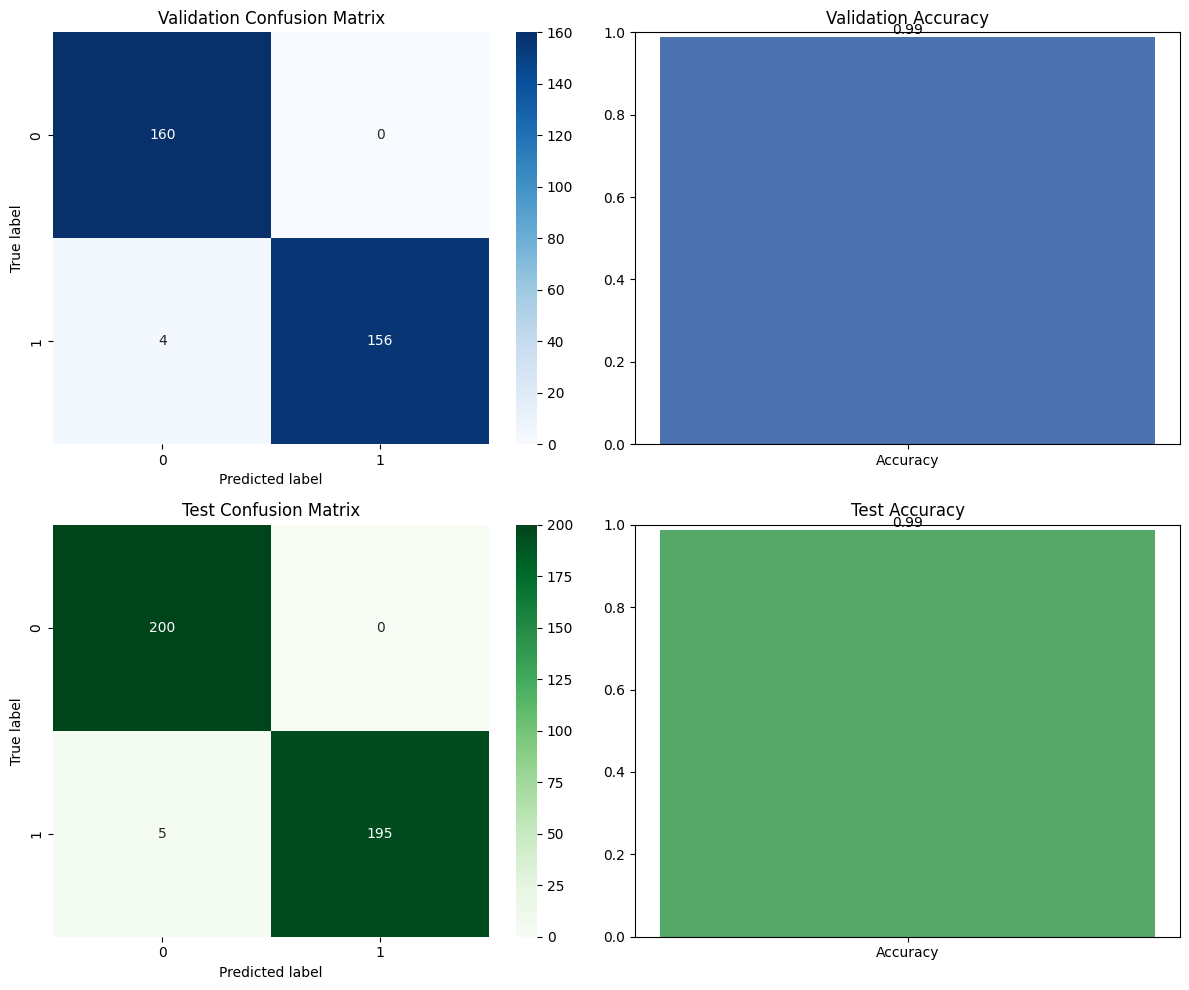

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns


# 1) Validation predictions and metrics
y_valid_pred = knn_all_feautres.predict(X_valid)
valid_acc = accuracy_score(y_valid, y_valid_pred)
valid_cm = confusion_matrix(y_valid, y_valid_pred)
valid_report = classification_report(y_valid, y_valid_pred, output_dict=True)

# 2) Test predictions and metrics
y_test_pred = knn_all_feautres.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_cm = confusion_matrix(y_test, y_test_pred)
test_report = classification_report(y_test, y_test_pred, output_dict=True)

# Class labels in consistent order (rows/cols). If y is categorical text, get unique labels from combined sets.
# Using sklearn's labels derived from confusion_matrix inputs preserves order of unique labels encountered.
labels = sorted(list(set(pd.concat([pd.Series(y_valid), pd.Series(y_test)]).unique())))

# Recompute confusion matrices explicitly with a fixed label order for consistent axes
valid_cm = confusion_matrix(y_valid, y_valid_pred, labels=labels)
test_cm  = confusion_matrix(y_test,  y_test_pred,  labels=labels)

# 3) Plot confusion matrices (validation and test) side-by-side
fig, axes = plt.subplots(2, 2, figsize=(12, 10), gridspec_kw={'height_ratios': [4, 4]})

# Validation confusion matrix heatmap
sns.heatmap(pd.DataFrame(valid_cm, index=labels, columns=labels),
            annot=True, fmt="d", cmap="Blues", cbar=True, ax=axes[0,0])
axes[0,0].set_title("Validation Confusion Matrix")
axes[0,0].set_xlabel("Predicted label")
axes[0,0].set_ylabel("True label")

# Validation accuracy bar
axes[0,1].bar(["Accuracy"], [valid_acc], color="#4C72B0")
axes[0,1].set_ylim(0, 1)
axes[0,1].bar_label(axes[0,1].containers[0], fmt="%.2f")
axes[0,1].set_title("Validation Accuracy")

# Test confusion matrix heatmap
sns.heatmap(pd.DataFrame(test_cm, index=labels, columns=labels),
            annot=True, fmt="d", cmap="Greens", cbar=True, ax=axes[1,0])
axes[1,0].set_title("Test Confusion Matrix")
axes[1,0].set_xlabel("Predicted label")
axes[1,0].set_ylabel("True label")

# Test accuracy bar
axes[1,1].bar(["Accuracy"], [test_acc], color="#55A868")
axes[1,1].set_ylim(0, 1)
axes[1,1].bar_label(axes[1,1].containers[0], fmt="%.2f")
axes[1,1].set_title("Test Accuracy")

plt.tight_layout()
plt.show()

# 4) Per-class precision/recall/F1 bar chart for validation
valid_df = (
    pd.DataFrame(valid_report)
      .T
      .reset_index()
      .rename(columns={"index": "label"})
)


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Prepare full extent (clip to reduce artifacts)
X_all = pd.concat([X_train, X_valid], axis=0)
pad = 1.0
x_min = X_all["tsne_x"].quantile(0.01) - pad
x_max = X_all["tsne_x"].quantile(0.99) + pad
y_min = X_all["tsne_y"].quantile(0.01) - pad
y_max = X_all["tsne_y"].quantile(0.99) + pad

# 2) Coarse grid for solid regions (fast + visually clean)
h = 0.25  # try 0.2–0.5; smaller = more detail, slower
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = knn_tsne.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# 3) Simple two-color background and all points on top
# Choose two solid background colors
from matplotlib.colors import ListedColormap
bg_cmap = ListedColormap(["#f46d43", "#66bd63"])  # orange/red vs green

plt.figure(figsize=(8, 5))
plt.pcolormesh(xx, yy, Z, cmap=bg_cmap, shading="nearest", alpha=0.35)

# Plot all points: train as circles, valid as squares; same color per class
# Map class -> color so it matches background classes
classes = np.unique(pd.concat([y_train, y_valid]))
point_colors = {c: bg_cmap.colors[i % len(bg_cmap.colors)] for i, c in enumerate(classes)}

# Valid
for cls in classes:
    m = y_valid == cls
    plt.scatter(X_valid.loc[m, "tsne_x"], X_valid.loc[m, "tsne_y"],
                c=point_colors[cls], edgecolors="k", s=25, marker="s")

# Labels and aspect
plt.xlim(x_min, x_max); plt.ylim(y_min, y_max)
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.title("K-NN (t-SNE space) —  valid")
plt.tight_layout()
plt.show()


KeyError: 'tsne_x'

c:\Users\Edas\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


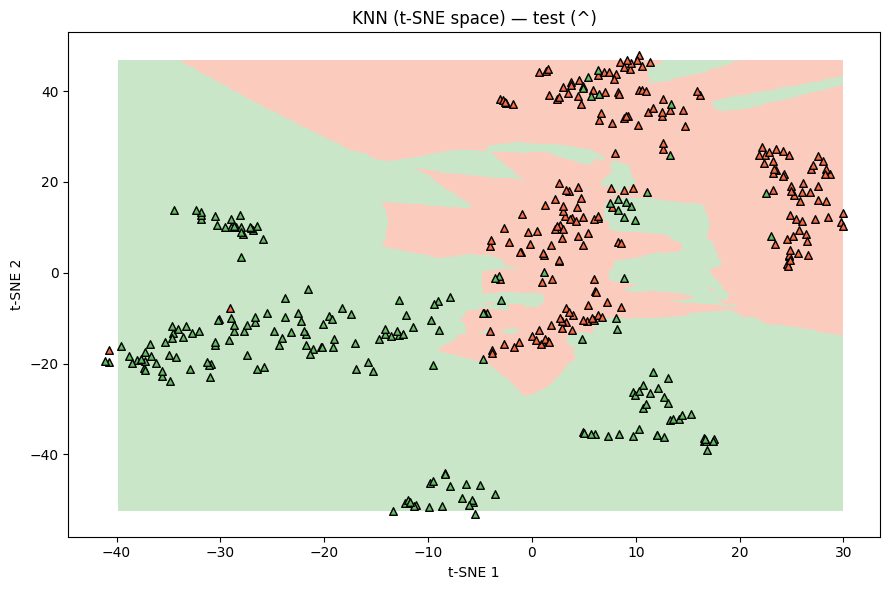

In [ ]:
# Assumes you already have:
# - knn_tsne fitted on X_train[['tsne_x','tsne_y']]
# - X_train, y_train, X_valid, y_valid, X_test, y_test with columns tsne_x, tsne_y

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 1) Rebuild or reuse the same grid over the combined extent (train+valid+test)
X_all = pd.concat([X_train, X_valid, X_test], axis=0)

pad, h = 1.0, 0.25
x_min = X_all["tsne_x"].quantile(0.01) - pad
x_max = X_all["tsne_x"].quantile(0.99) + pad
y_min = X_all["tsne_y"].quantile(0.01) - pad
y_max = X_all["tsne_y"].quantile(0.99) + pad
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn_tsne.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# 2) Consistent two-color background
bg_cmap = ListedColormap(["#f46d43", "#66bd63"])  # orange vs green
plt.figure(figsize=(9, 6))
plt.pcolormesh(xx, yy, Z, cmap=bg_cmap, shading="nearest", alpha=0.35)

# 3) Color mapping for points to match classes
classes = np.unique(pd.concat([y_train, y_valid, y_test]))
point_colors = {c: bg_cmap.colors[i % len(bg_cmap.colors)] for i, c in enumerate(classes)}

for cls in classes:
    m = y_test == cls
    plt.scatter(X_test.loc[m, "tsne_x"], X_test.loc[m, "tsne_y"],
                c=point_colors[cls], edgecolors="k", s=30, marker="^")  # test as triangles

plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.title("KNN (t-SNE space) — test (^)")
plt.tight_layout(); plt.show()
